In [85]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [86]:
def relativeFilePath(path):
    return os.path.join(os.path.dirname(os.path.abspath('')), path)

In [107]:
omegaMaxRawData=[
    [np.loadtxt(relativeFilePath("specrec_results/RhoOverOmega_meanTraining_data_wilson_emconduc_48_16_b6.872_B2_x_oM_100.txt"),unpack=True),100],
    # [np.loadtxt(relativeFilePath("specrec_results/RhoOverOmega_meanTraining_data_wilson_emconduc_48_16_b6.872_B2_x_oM_50.txt"),unpack=True),50],
    [np.loadtxt(relativeFilePath("specrec_results/RhoOverOmega_meanTraining_data_wilson_emconduc_48_16_b6.872_B2_x_oM_50_2.txt"),unpack=True),50],
    # [np.loadtxt(relativeFilePath("specrec_results/RhoOverOmega_meanTraining_data_wilson_emconduc_48_16_b6.872_B2_x_oM_20.txt"),unpack=True),20],
        [np.loadtxt(relativeFilePath("specrec_results/RhoOverOmega_meanTraining_data_wilson_emconduc_48_16_b6.872_B2_x_oM_20_2.txt"),unpack=True),20],
    [np.loadtxt(relativeFilePath("specrec_results/RhoOverOmega_meanTraining_data_wilson_emconduc_48_16_b6.872_B2_x_oM_10.txt"),unpack=True),10],
    [np.loadtxt(relativeFilePath("specrec_results/RhoOverOmega_meanTraining_data_wilson_emconduc_48_16_b6.872_B2_x_oM_6.txt" ),unpack=True),6],
]

omegaMaxData=[]
for data,l in omegaMaxRawData:
    omega=data[0]
    rhoOverOmega_mean=data[1,:]
    rhoOverOmega_error=data[2,:]
    rhoOverOmega_samples=data[3:,:]
    omegaMaxData.append([omega,rhoOverOmega_mean,rhoOverOmega_error,rhoOverOmega_samples,l])
    

Text(0, 0.5, 'rho/omega')

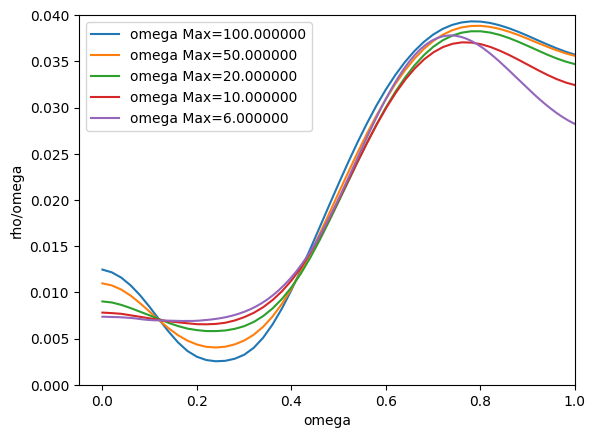

In [104]:
for data in omegaMaxData:
    plt.plot(data[0],data[1],label="omega Max=%f"%data[-1])

plt.xlim(-0.05,1)
plt.ylim(0,0.04)
plt.legend()
plt.xlabel("omega")
plt.ylabel("rho/omega")

Text(0.5, 0, 'omega Max')

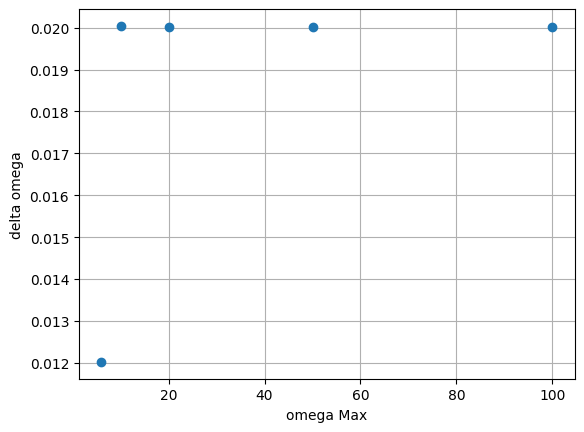

In [95]:
delta_omegas=np.array([data[0][1]-data[0][0] for data in omegaMaxData])
omegaMaxValues=np.array([data[-1] for data in omegaMaxData])

plt.plot(omegaMaxValues,delta_omegas,"o")
plt.grid()
plt.ylabel("delta omega")
plt.xlabel("omega Max")

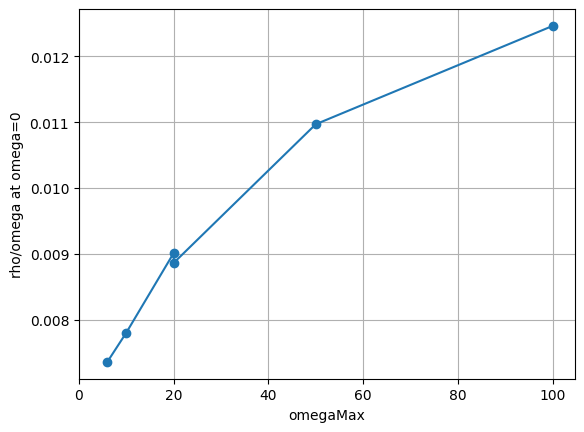

In [108]:
# plot first points as function of omegaMax
omegaMaxValues=np.array([data[-1] for data in omegaMaxData])
rhoOverOmegaValues=np.array([data[1][0] for data in omegaMaxData])
plt.figure()
plt.plot(omegaMaxValues,rhoOverOmegaValues,marker='o')
# plt.plot(np.linspace(0,100,1000),np.linspace(0,100,1000)*0.0021/20+0.0067)
plt.xlabel("omegaMax")
plt.ylabel("rho/omega at omega=0")
plt.xlim(0,None)
plt.grid()


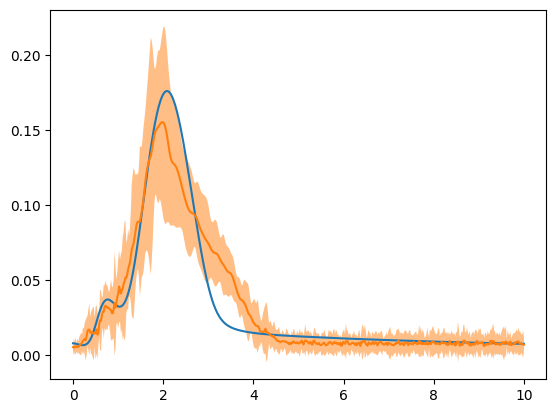

In [49]:
plt.plot(omega,rhoOverOmega_mean)
plt.fill_between(omega,rhoOverOmega_mean-rhoOverOmega_error,rhoOverOmega_mean+rhoOverOmega_error,alpha=0.5)
# plt.plot(omega,rhoOverOmega_samples.T,alpha=0.1,color='black')
# plt.xlim(None,1)
# plt.ylim(0,0.05)
resultsfile="RhoOverOmega_meanTraining_data_wilson_emconduc_48_16_b6.872_B2_x (copy).txt"
data=np.loadtxt(resultsfile,unpack=True)
omega=data[0]
rhoOverOmega_mean=data[1]
rhoOverOmega_error=data[2]
rhoOverOmega_samples=data[3:]

plt.plot(omega,rhoOverOmega_mean)
plt.fill_between(omega,rhoOverOmega_mean-rhoOverOmega_error,rhoOverOmega_mean+rhoOverOmega_error,alpha=0.5)
# plt.plot(omega,rhoOverOmega_samples.T,alpha=0.1,color='black')

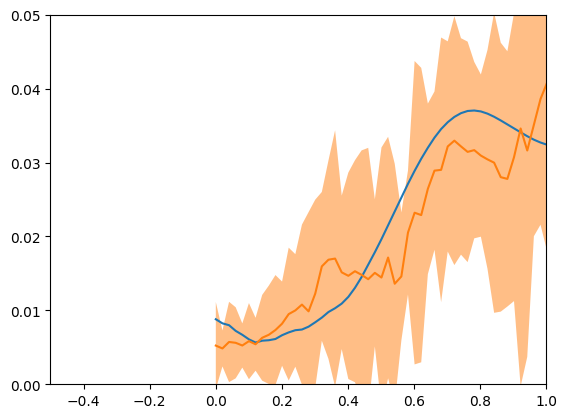

In [43]:
plt.plot(omega,rhoOverOmega_mean)
plt.fill_between(omega,rhoOverOmega_mean-rhoOverOmega_error,rhoOverOmega_mean+rhoOverOmega_error,alpha=0.5)
# plt.plot(omega,rhoOverOmega_samples.T,alpha=0.1,color='black')
plt.xlim(None,1)
plt.ylim(0,0.05)
resultsfile="RhoOverOmega_meanTraining_data_wilson_emconduc_48_16_b6.872_B2_x (copy).txt"
data=np.loadtxt(resultsfile,unpack=True)
omega=data[0]
rhoOverOmega_mean=data[1]
rhoOverOmega_error=data[2]
rhoOverOmega_samples=data[3:]

plt.plot(omega,rhoOverOmega_mean)
plt.fill_between(omega,rhoOverOmega_mean-rhoOverOmega_error,rhoOverOmega_mean+rhoOverOmega_error,alpha=0.5)
# plt.plot(omega,rhoOverOmega_samples.T,alpha=0.1,color='black')

# checkCorrelator reconstruction

In [46]:
import correlator

Nt=16

true_correlator=np.loadtxt("data_wilson_emconduc_48_16_b6.872_B2_x.txt",unpack=True)

x=true_correlator[0,:]
Dxi=true_correlator[1,:]
error=true_correlator[2,:]

2025-02-04 14:45:27.768890: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-04 14:45:27.769433: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-04 14:45:27.771460: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-04 14:45:27.776089: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738676727.783624   29582 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738676727.78

In [123]:
true_correlator.shape

(13, 16)

/home/lpannullo/professional/projects/SpectralFunctionWithML/correlator.py:20: RuntimeWarning: overflow encountered in cosh
  ker = np.cosh(Omega * (Position-1/(2*T))) / np.sinh(Omega/2/T)
/home/lpannullo/professional/projects/SpectralFunctionWithML/correlator.py:20: RuntimeWarning: overflow encountered in sinh
  ker = np.cosh(Omega * (Position-1/(2*T))) / np.sinh(Omega/2/T)
/home/lpannullo/professional/projects/SpectralFunctionWithML/correlator.py:20: RuntimeWarning: invalid value encountered in divide
  ker = np.cosh(Omega * (Position-1/(2*T))) / np.sinh(Omega/2/T)


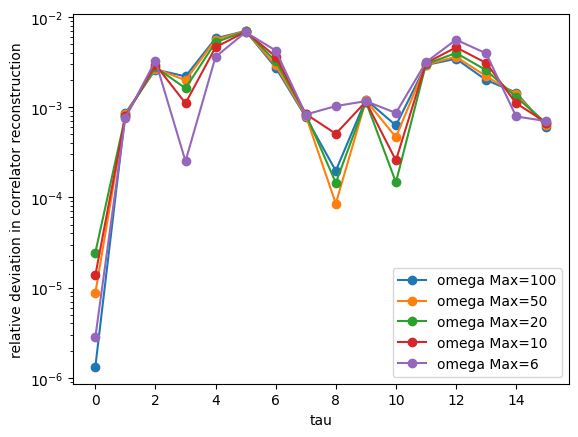

In [83]:
for data in omegaMaxData:
    omega=data[0]
    delomega=omega[1]-omega[0]
    rhoOverOmega_mean=data[1]
    kernel=kernel=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_FiniteT,x,omega,args=(1/Nt,))
    corr=correlator.Di(kernel,rhoOverOmega_mean,delomega).numpy()
    # relative deviation
    deviation=np.abs((corr-Dxi)/Dxi)
    plt.plot(x,deviation,label="omega Max=%d"%data[-1],marker='o')
plt.yscale("log")
plt.xlabel("tau")
plt.ylabel("relative deviation in correlator reconstruction")
plt.legend()

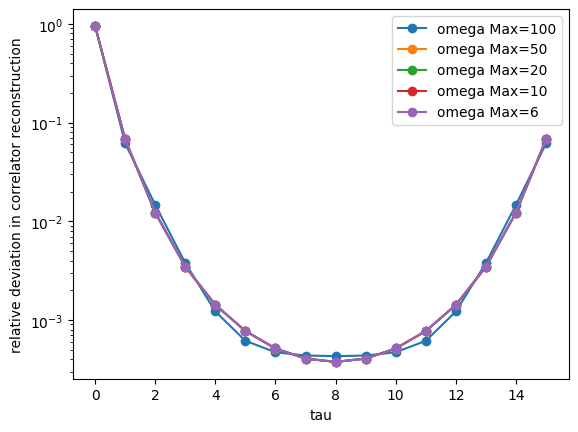

In [48]:
for data in omegaMaxData:
    omega=data[0]
    delomega=omega[1]-omega[0]
    rhoOverOmega_mean=data[1]
    kernel=kernel=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_FiniteT,x,omega,args=(1/Nt,))
    corr=correlator.Di(kernel,rhoOverOmega_mean,delomega).numpy()
    # relative deviation
    plt.plot(x,corr,label="omega Max=%d"%data[-1],marker='o')
plt.yscale("log")
plt.xlabel("tau")
plt.ylabel("relative deviation in correlator reconstruction")
plt.legend()

In [121]:
corr

array([0.95440596, 0.07391547, 0.9492535 , 0.07409276, 0.07389017,
       0.0738756 , 0.0739032 , 0.07388275, 0.07382274, 0.07397216,
       0.07390662, 0.07396912, 0.07383995], dtype=float32)

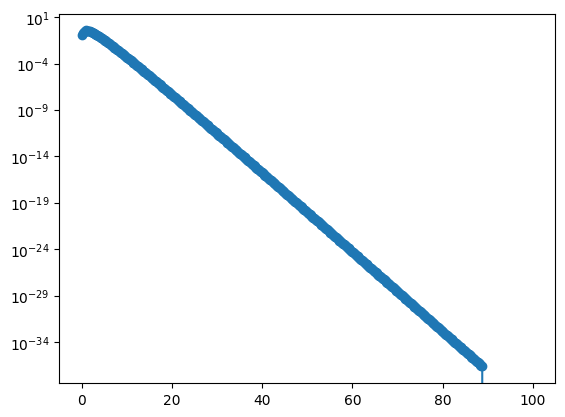

In [40]:
a=np.array([  1.25000000e-01, 1.81267757e-01, 2.69874383e-01, 3.29645153e-01,
       3.59612328e-01, 3.67879041e-01, 3.61287515e-01, 3.44958428e-01,
       3.22645597e-01, 2.97060770e-01, 2.70128142e-01, 2.43180952e-01,
       2.17112662e-01, 1.92492714e-01, 1.69654748e-01, 1.48763463e-01,
       1.29864976e-01, 1.12924458e-01, 9.78540124e-02, 8.45330953e-02,
       7.28232746e-02, 6.25787005e-02, 5.36533649e-02, 4.59059688e-02,
       3.92030269e-02, 3.34206895e-02, 2.84456448e-02, 2.41753759e-02,
       2.05179771e-02, 1.73916804e-02, 1.47242045e-02, 1.24520059e-02,
       1.05194889e-02, 8.87821460e-03, 7.48613497e-03, 6.30686911e-03,
       5.30903162e-03, 4.46561804e-03, 3.75344869e-03, 3.15267013e-03,
       2.64631144e-03, 2.21989205e-03, 1.86107694e-03, 1.55937487e-03,
       1.30587555e-03, 1.09302140e-03, 9.14410112e-04, 7.64624279e-04,
       6.39084819e-04, 5.33925154e-04, 4.45883440e-04, 3.72210442e-04,
       3.10590922e-04, 2.59076679e-04, 2.16029594e-04, 1.80073256e-04,
       1.50051932e-04, 1.24995811e-04, 1.04091588e-04, 8.66576066e-05,
       7.21228644e-05, 6.00093039e-05, 4.99168856e-05, 4.15110175e-05,
       3.45119772e-05, 2.86860176e-05, 2.38378936e-05, 1.98045867e-05,
       1.64500389e-05, 1.36607375e-05, 1.13420128e-05, 9.41493833e-06,
       7.81373476e-06, 6.48359780e-06, 5.37888134e-06, 4.46157856e-06,
       3.70005271e-06, 3.06797688e-06, 2.54344879e-06, 2.10825201e-06,
       1.74723957e-06, 1.44781985e-06, 1.19952802e-06, 9.93668850e-07,
       8.23019086e-07, 6.81579601e-07, 5.64368996e-07, 4.67251804e-07,
       3.86795527e-07, 3.20151703e-07, 2.64956975e-07, 2.19250846e-07,
       1.81407296e-07, 1.50077957e-07, 1.24144891e-07, 1.02681367e-07,
       8.49192806e-08, 7.02221052e-08, 5.80624322e-08, 4.80033317e-08,
       3.96828837e-08, 3.28013437e-08, 2.71104965e-08, 2.24048253e-08,
       1.85141899e-08, 1.52977554e-08, 1.26389593e-08, 1.04413407e-08,
       8.62508296e-09, 7.12415010e-09, 5.88391359e-09, 4.85918705e-09,
       4.01259843e-09, 3.31324200e-09, 2.73556226e-09, 2.25842998e-09,
       1.86437734e-09, 1.53896494e-09, 1.27025791e-09, 1.04839249e-09,
       8.65217358e-10, 7.13996998e-10, 5.89166281e-10, 4.86127514e-10,
       4.01082593e-10, 3.30894219e-10, 2.72971150e-10, 2.25173336e-10,
       1.85733503e-10, 1.53192332e-10, 1.26344897e-10, 1.04196394e-10,
       8.59255580e-11, 7.08544463e-11, 5.84234641e-11, 4.81707393e-11,
       3.97150843e-11, 3.27419232e-11, 2.69916692e-11, 2.22501270e-11,
       1.83405674e-11, 1.51171834e-11, 1.24596875e-11, 1.02688517e-11,
       8.46282528e-12, 6.97409602e-12, 5.74698169e-12, 4.73555986e-12,
       3.90195942e-12, 3.21495086e-12, 2.64878292e-12, 2.18222282e-12,
       1.79776438e-12, 1.48097474e-12, 1.21995547e-12, 1.00489803e-12,
       8.27717111e-13, 6.81748239e-13, 5.61498366e-13, 4.62440191e-13,
       3.80842553e-13, 3.13630579e-13, 2.58270365e-13, 2.12673904e-13,
       1.75120700e-13, 1.44193146e-13, 1.18723256e-13, 9.77487518e-14,
       8.04768685e-14, 6.62545227e-14, 5.45437237e-14, 4.49013099e-14,
       3.69622487e-14, 3.04258751e-14, 2.50445517e-14, 2.06143241e-14,
       1.69672226e-14, 1.39649181e-14, 1.14934965e-14, 9.45915262e-15,
       7.78464378e-15, 6.40636756e-15, 5.27195510e-15, 4.33828863e-15,
       3.56986845e-15, 2.93746808e-15, 2.41702649e-15, 1.98873588e-15,
       1.63629043e-15, 1.34626757e-15, 1.10761854e-15, 9.11248909e-16,
       7.49673088e-16, 6.16729949e-16, 5.07348636e-16, 4.17355764e-16,
       3.43316688e-16, 2.82404821e-16, 2.32294062e-16, 1.91070232e-16,
       1.57158179e-16, 1.29261767e-16, 1.06314485e-16, 8.74387910e-17,
       7.19126531e-17, 5.91420049e-17, 4.86380819e-17, 3.99987669e-17,
       3.28932382e-17, 2.70493366e-17, 2.22431692e-17, 1.82905541e-17,
       1.50399817e-17, 1.23668213e-17, 1.01685562e-17, 8.36086130e-18,
       6.87437703e-18, 5.65205485e-18, 4.64697317e-18, 3.82054065e-18,
       3.14101802e-18, 2.58230216e-18, 2.12292571e-18, 1.74523423e-18,
       1.43470931e-18, 1.17941176e-18, 9.69523661e-19, 7.96971642e-19,
       6.55117040e-19, 5.38501068e-19, 4.42635213e-19, 3.63828857e-19,
       2.99047506e-19, 2.45796197e-19, 2.02023612e-19, 1.66043231e-19,
       1.36468480e-19, 1.12159415e-19, 9.21788706e-20, 7.57564063e-20,
       6.22586562e-20, 5.11649532e-20, 4.20472834e-20, 3.45538058e-20,
       2.83953011e-20, 2.33340312e-20, 1.91745789e-20, 1.57563173e-20,
       1.29472187e-20, 1.06387643e-20, 8.74176016e-21, 7.18289697e-21,
       5.90192239e-21, 4.84931630e-21, 3.98437995e-21, 3.27366509e-21,
       2.68968282e-21, 2.20984221e-21, 1.81557789e-21, 1.49163299e-21,
       1.22546977e-21, 1.00678515e-21, 8.27112571e-22, 6.79494767e-22,
       5.58214782e-22, 4.58574939e-22, 3.76715177e-22, 3.09463747e-22,
       2.54214519e-22, 2.08826146e-22, 1.71539206e-22, 1.40908101e-22,
       1.15745099e-22, 9.50743559e-23, 7.80941218e-23, 6.41456949e-23,
       5.26879062e-23, 4.32761547e-23, 3.55451809e-23, 2.91949123e-23,
       2.39788328e-23, 1.96944278e-23, 1.61753316e-23, 1.32848776e-23,
       1.09107976e-23, 8.96086754e-24, 7.35932984e-24, 6.04395427e-24,
       4.96362311e-24, 4.07634742e-24, 3.34763719e-24, 2.74916251e-24,
       2.25765363e-24, 1.85399739e-24, 1.52249497e-24, 1.25025209e-24,
       1.02667816e-24, 8.43074782e-25, 6.92297800e-25, 5.68479638e-25,
       4.66801258e-25, 3.83304834e-25, 3.14739885e-25, 2.58436889e-25,
       2.12203478e-25, 1.74239169e-25, 1.43065335e-25, 1.17467683e-25,
       9.64490115e-26, 7.91904082e-26, 6.50193814e-26, 5.33836871e-26,
       4.38298323e-26, 3.59854212e-26, 2.95446561e-26, 2.42564300e-26,
       1.99145478e-26, 1.63496954e-26, 1.34228446e-26, 1.10198368e-26,
       9.04693552e-27, 7.42717380e-27, 6.09735475e-27, 5.00558859e-27,
       4.10927000e-27, 3.37341729e-27, 2.76930853e-27, 2.27336167e-27,
       1.86621494e-27, 1.53197174e-27, 1.25758061e-27, 1.03232614e-27,
       8.47410913e-28, 6.95612280e-28, 5.71000530e-28, 4.68707485e-28,
       3.84736507e-28, 3.15806496e-28, 2.59223814e-28, 2.12777122e-28,
       1.74651045e-28, 1.43355278e-28, 1.17666396e-28, 9.65800673e-29,
       7.92718263e-29, 6.50648682e-29, 5.34036075e-29, 4.38319719e-29,
       3.59755810e-29, 2.95271164e-29, 2.42343118e-29, 1.98900924e-29,
       1.63244811e-29, 1.33979535e-29, 1.09959830e-29, 9.02456317e-30,
       7.40653146e-30, 6.07855188e-30, 4.98863783e-30, 4.09411875e-30,
       3.35997097e-30, 2.75744757e-30, 2.26295371e-30, 1.85712340e-30,
       1.52406173e-30, 1.25072283e-30, 1.02639927e-30, 8.42303010e-31,
       6.91221351e-31, 5.67234621e-31, 4.65484394e-31, 3.81983276e-31,
       3.13458764e-31, 2.57225101e-31, 2.11078089e-31, 1.73208762e-31,
       1.42132525e-31, 1.16631004e-31, 9.57043114e-32, 7.85318721e-32,
       6.44402735e-32, 5.28768764e-32, 4.33881584e-32, 3.56019401e-32,
       2.92127979e-32, 2.39700917e-32, 1.96681408e-32, 1.61381596e-32,
       1.32416409e-32, 1.08649247e-32, 8.91474166e-33, 7.31455568e-33,
       6.00156201e-33, 4.92422421e-33, 4.04025269e-33, 3.31494586e-33,
       2.71982880e-33, 2.23153615e-33, 1.83089538e-33, 1.50217452e-33,
       1.23246480e-33, 1.01117411e-33, 8.29611304e-34, 6.80645052e-34,
       5.58423965e-34, 4.58146891e-34, 3.75874438e-34, 3.08374320e-34,
       2.52994452e-34, 2.07558814e-34, 1.70282009e-34, 1.39699152e-34,
       1.14608334e-34, 9.40234265e-35, 7.71353405e-35, 6.32802512e-35,
       5.19135187e-35, 4.25882925e-35, 3.49379559e-35, 2.86617215e-35,
       2.35128123e-35, 1.92887649e-35, 1.58234731e-35, 1.29806598e-35,
       1.06485210e-35, 8.73533178e-36, 7.16584007e-36, 5.87830918e-36,
       4.82209050e-36, 3.95563233e-36, 3.24484621e-36, 2.66176660e-36,
       2.18345118e-36, 1.79107871e-36, 1.46920888e-36, 1.20517498e-36,
       9.88585824e-37, 8.10916923e-37, 6.65175240e-37, 5.45624072e-37,
       4.47557374e-37, 3.67114609e-37, 3.01128863e-37, 2.47002233e-37,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])
plt.plot(np.linspace(0,100,500),a,marker='o')
plt.yscale("log")